# S9 — Single-point assimilation, from scratch, in pure Python

**Question:** is the sign flip (truth strong updraft → prior weak updraft → analysis strong
downdraft) a **bug in the assimilation code**, or a **real consequence of the conditions**
(departure, spread, `cov(w, dBZ)`, nonlinear H)?

**Test:** re-derive the analysis at one grid point *by hand* in NumPy — no Fortran in the
derivation — following the exact production logic, and check it reproduces the stored production
value. This is done **only at loc = 0.1 km (a single observation)**, the one fully self-contained,
fair comparison: there the single observation *is* the analysis cell, so the update depends on
nothing but that cell's own prior ensemble. Localization and neighbouring observations play no role.

**What a pass means.** If the pure-Python result matches the production `mean_a_point_w` to several
decimals, the update code is correct and the flip is physical. Then whatever *extra* damage appears
at larger localization (loc = 2.0) must come from **localization itself or the covariances induced
by neighbouring observations** — the next thing to look at, separately.

Three checks, in order of strength:
1. **pure-Python core == Fortran core** (`simple_letkf_wloc` as an oracle on the same inputs);
2. **pure-Python == production** (the stored sweep `mean_a_point_w`);
3. **LETKF transform == scalar Kalman** `Δw = dep·cov(w,h)/(var(h)+R)` (the mechanism reading).

The notebook is reusable: set `CELL` to any point — another severe point, or one where the analysis
is *worse than the prior*.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

REPO   = '/nfsmounts/munin/datos/jorge.gacitua/WRF_Single_Cycle_Assimilation'
SUBSET = f'{REPO}/data/3D_subsets_20240319_GUES_20240319180000/subset_20240319180000.npz'
SWEEP  = f'{REPO}/data/WS_singleobs_xsec_1800_GUES/WS_singleobs_xsec_1800_GUES_sweep_Ne059_tm00.npz'
sys.path.insert(0, f'{REPO}/src/fortran')          # cda is a VALIDATION ORACLE ONLY

VI   = {'qg': 0, 'qr': 1, 'qs': 2, 'T': 3, 'P': 4, 'u': 5, 'v': 6, 'w': 7}
VARS = ['qg', 'qr', 'qs', 'T', 'P', 'u', 'v', 'w']
IW   = VI['w']

R0      = 5.0        # obs.obs_error_var
DBZ_MIN = 0.0        # qc.dbz_min (clamp_obs: true)
TM      = 0          # truth member; prior = members 1..59
PI, RD  = 3.14159265358979, 287.0      # common_tools.f90 (pi, rd)

CELL = (434, 554, 5)          # target point (severe: w_f=+0.14, w_a=-1.00, w_truth=+3.25)

# per-variable PHYSICAL tolerances (state space). An absolute atol mis-scales: P ~ 9e4 Pa, so a
# couple of float32 ULPs on P is ~1e-2, while w ~ 1 m/s. (finish_diag1800.py:33)
TOL = dict(qg=1e-6, qr=1e-6, qs=1e-6, T=1e-2, P=1.0, u=1e-3, v=1e-3, w=1e-3)
print(f'target CELL = {CELL}')

target CELL = (434, 554, 5)


In [2]:
# ===========================================================================
# H  -- reflectivity forward operator, ported verbatim from calc_ref
#       (common_da_wloc.f90:228-307, Tong & Xue 2006).  qr,qs,qg,T,P only.
# ===========================================================================
def calc_ref_np(qr, qs, qg, T, P, min_dbz=DBZ_MIN):
    qr, qs, qg, T, P = (np.asarray(a, np.float64) for a in (qr, qs, qg, T, P))
    nor, nos, nog = 8.0e6, 2.0e6, 4.0e6
    ror, ros, rog, roi = 1000.0, 100.0, 913.0, 917.0
    ki2, kr2 = 0.176, 0.930
    pip = PI ** 1.75
    cf  = 1e18 * 720.0 / (pip * nor**0.75 * ror**1.75)
    cf2 = 1e18 * 720.0 * ki2 * ros**0.25 / (pip * kr2 * nos**0.75 * roi**2.0)
    cf3 = 1e18 * 720.0 / (pip * nos**0.75 * ros**1.75)
    cf4 = (1e18 * 720.0 / (pip * nog**0.75 * rog**1.75)) ** 0.95
    ro = P / (RD * T)
    zr = np.where(qr > 0.0, cf * (ro * qr) ** 1.75, 0.0)
    qs_ = np.maximum(qs, 0.0)                            # snow branch: dry (T<=273.16) / wet
    zs = np.where(qs > 0.0, np.where(T <= 273.16, cf2, cf3) * (ro * qs_) ** 1.75, 0.0)
    zg = np.where(qg > 0.0, cf4 * (ro * qg) ** 1.6625, 0.0)
    z  = zr + zs + zg
    ref = np.where(z > 0.0, 10.0 * np.log10(np.where(z > 0.0, z, 1.0)), min_dbz)
    return np.maximum(ref, min_dbz)                      # floor at dbz_min


# validate the port against the Fortran calc_ref on a synthetic spread of inputs
from cletkf_wloc import common_da as cda
_rng = np.random.default_rng(0)
_n = 4000
_qr = _rng.uniform(0, 3e-3, _n); _qs = _rng.uniform(0, 3e-3, _n); _qg = _rng.uniform(0, 3e-3, _n)
_T = _rng.uniform(220, 300, _n); _P = _rng.uniform(2e4, 1e5, _n)
_np = calc_ref_np(_qr, _qs, _qg, _T, _P)
_ft = np.array([cda.calc_ref(_qr[i], _qs[i], _qg[i], _T[i], _P[i], min_dbz=DBZ_MIN) for i in range(_n)])
_ft = np.maximum(_ft, DBZ_MIN)
print(f'H port vs Fortran calc_ref on {_n} random inputs: max|d| = {np.abs(_np - _ft).max():.2e} dBZ')
assert np.abs(_np - _ft).max() < 1e-4, 'H port disagrees with Fortran'

H port vs Fortran calc_ref on 4000 random inputs: max|d| = 0.00e+00 dBZ


In [3]:
# ===========================================================================
# LETKF core -- exactly common_letkf.f90, at one grid point.
#   C = hdxb^T R^-1 hdxb + (Ne-1) I    (rho = 1/parm_infl = 1)
#   Pa = C^-1 ;  wamean = Pa hdxb_rinv^T dep ;  T = sqrt((Ne-1) Pa) (symmetric root)
# LAPACK dsyev (the Fortran path) == np.linalg.eigh; Pa/wamean/T are invariant to eigen
# sign & order, so the port is exact up to float64 round-off.
# ===========================================================================
def letkf_core_np(hdxb, rloc, dep, Ne):
    hdxb = np.atleast_2d(np.asarray(hdxb, np.float64))          # (nobsl, Ne)
    rloc = np.atleast_1d(np.asarray(rloc, np.float64))          # (nobsl,)
    dep  = np.atleast_1d(np.asarray(dep,  np.float64))          # (nobsl,)
    hdxb_rinv = hdxb / rloc[:, None]
    C = hdxb_rinv.T @ hdxb
    C[np.diag_indices(Ne)] += (Ne - 1)
    eival, eivec = np.linalg.eigh(C)
    Pa     = (eivec / eival) @ eivec.T
    wamean = Pa @ (hdxb_rinv.T @ dep)
    T      = (eivec * np.sqrt((Ne - 1) / eival)) @ eivec.T
    return wamean, T, Pa


def apply_weights(xfmean, xfpert, wamean, T):
    # common_da_wloc.f90:163-171 : xa[im] = xfmean + sum_im2 xfpert[im2]*(T[im2,im]+wamean[im2])
    W = T + wamean[:, None]
    return xfmean[None, :] + W.T @ xfpert                       # (Ne, nvar)


def Hens(x):
    return calc_ref_np(x[:, VI['qr']], x[:, VI['qs']], x[:, VI['qg']], x[:, VI['T']], x[:, VI['P']])


def clamp_hydro(x):
    for v in ('qr', 'qs', 'qg'):
        x[:, VI[v]] = np.maximum(x[:, VI[v]], 0.0)
    return x


def tempering_schedule(ntemp, alpha_s):                        # core.py:96-106
    if ntemp == 1:
        return np.array([1.0])
    i = np.arange(1, ntemp + 1, dtype=np.float64)
    w = np.exp(-(ntemp + 1) * float(alpha_s) / i)
    return w / w.sum()

In [4]:
# ===========================================================================
# Single-cell method wrappers.  Each takes the cell's prior ensemble xf (Ne, nvar) and the
# scalar obs yo, and returns (xa (Ne,nvar), trace-dict).  The obs IS the cell, so rloc = oerr
# (localization weight exp(0)=1) and there is exactly one observation.
# ===========================================================================
def letkf_point(xf, yo, R0=R0):
    Ne = xf.shape[0]
    xm, xp = xf.mean(0), xf - xf.mean(0)
    h = Hens(xf); hm = h.mean(); hp = h - hm
    dep = yo - hm
    wa, T, Pa = letkf_core_np(hp, [R0], [dep], Ne)
    xa = apply_weights(xm, xp, wa, T)
    return xa, dict(h=h, hm=hm, hp=hp, dep=dep, rloc=R0, wamean=wa, T=T, Pa=Pa)


def aoei_point(xf, yo, R0=R0):
    Ne = xf.shape[0]
    xm, xp = xf.mean(0), xf - xf.mean(0)
    h = Hens(xf); hm = h.mean(); hp = h - hm
    dep = yo - hm
    Rt = max(R0, dep**2 - h.var(ddof=1))                       # core.py:139-148
    wa, T, Pa = letkf_core_np(hp, [Rt], [dep], Ne)
    xa = apply_weights(xm, xp, wa, T)
    return xa, dict(h=h, hm=hm, dep=dep, rloc=Rt, R_tilde=Rt, wamean=wa)


def tenkf_point(xf, yo, ntemp, alpha_s=1.0, R0=R0):
    Ne = xf.shape[0]
    steps = tempering_schedule(ntemp, alpha_s)
    x = xf.copy(); trace = []
    for it in range(len(steps)):                               # core.py:234-253
        h = Hens(x); hm = h.mean()                             # H re-evaluated on the UPDATED ens
        dep = yo - hm; oerr = R0 / steps[it]
        xm, xp = x.mean(0), x - x.mean(0)
        wa, T, _ = letkf_core_np(h - hm, [oerr], [dep], Ne)
        x = clamp_hydro(apply_weights(xm, xp, wa, T))
        trace.append(dict(step=it + 1, alpha=steps[it], oerr=oerr, dep=dep, w=x[:, IW].mean()))
    return x, dict(steps=steps, trace=trace)

print('method wrappers ready')

method wrappers ready


In [5]:
# ===========================================================================
# Load the sweep and build the point selector.  Candidates:
#   severe          : truth updraft, prior updraft, analysis downdraft  (the flip)
#   worse-than-prior: |error_a| > |error_f| for w  (rmse_*_point_* are single-point |error|)
# ===========================================================================
sw = np.load(SWEEP, allow_pickle=True)
_meth, _nt = sw['method'].astype(str), sw['ntemp']
_i, _j, _k = sw['i'], sw['j'], sw['k']
_base = (_meth == 'TEnKF') & (_nt == 1)                        # TEnKF Nt=1 == plain LETKF

fw = sw['mean_f_point_w'][_base]; aw = sw['mean_a_point_w'][_base]; tw = sw['truth_point_w'][_base]
bi, bj, bk = _i[_base], _j[_base], _k[_base]
with np.errstate(invalid='ignore'):
    severe = (tw > 1.0) & (fw > 0.0) & (aw < -1.0) & (bk >= 2)
    worse  = (np.abs(sw['rmse_a_point_w'][_base]) > np.abs(sw['rmse_f_point_w'][_base])) & (bk >= 2) \
             if 'rmse_a_point_w' in sw.files else np.zeros_like(severe)

sev_cells = list(zip(bi[severe].tolist(), bj[severe].tolist(), bk[severe].tolist()))
wor_cells = list(zip(bi[worse].tolist(),  bj[worse].tolist(),  bk[worse].tolist()))
print(f'severe (flip) candidates, k>=2 : {len(sev_cells)}   e.g. {sev_cells[:5]}')
print(f'worse-than-prior candidates    : {len(wor_cells)}   e.g. {wor_cells[:5]}')

# cells whose ensemble we will extract (target + a handful for interactive reuse)
CANDIDATES = sorted(set([CELL] + sev_cells[:8] + wor_cells[:4]))
assert CELL in set(sev_cells) or CELL in set(wor_cells) or True
print(f'\nCELL = {CELL}   (severe: {CELL in set(sev_cells)},  worse-than-prior: {CELL in set(wor_cells)})')
print(f'will extract {len(CANDIDATES)} cell ensembles')

severe (flip) candidates, k>=2 : 24   e.g. [(434, 554, 5), (216, 390, 5), (224, 382, 4), (224, 382, 5), (190, 690, 5)]
worse-than-prior candidates    : 293693   e.g. [(246, 318, 4), (246, 318, 6), (246, 318, 8), (246, 318, 9), (246, 320, 3)]

CELL = (434, 554, 5)   (severe: True,  worse-than-prior: True)
will extract 12 cell ensembles


In [6]:
# ===========================================================================
# Load state_ensemble ONCE (DEFLATE-compressed, ~53 s, 10.6 GB; cannot slice on disk),
# extract the candidate cells' prior ensembles + truth, then free the big array.
# ===========================================================================
import time
t0 = time.time()
with np.load(SUBSET) as f:
    se  = f['state_ensemble']                              # (nx,ny,nz,60,8)
    pos = f['pos_km'].astype(np.float64)
    XF, TRUTH = {}, {}
    for (ci, cj, ck) in CANDIDATES:
        XF[(ci, cj, ck)]    = se[ci, cj, ck, 1:60, :].astype(np.float64).copy()   # members 1..59
        TRUTH[(ci, cj, ck)] = se[ci, cj, ck, TM, :].astype(np.float64).copy()
    del se
print(f'extracted {len(XF)} ensembles in {time.time() - t0:.0f} s; each xf = {XF[CELL].shape} (Ne, nvar)')
Ne = XF[CELL].shape[0]
print(f'Ne = {Ne}')

extracted 12 ensembles in 54 s; each xf = (59, 8) (Ne, nvar)
Ne = 59


In [7]:
# ===========================================================================
# Gather the single-obs assimilation conditions for CELL, and check the INPUTS match production.
# ===========================================================================
def stored_row(cell, method, ntemp, key):
    m = (_meth == method) & (_nt == ntemp) & (_i == cell[0]) & (_j == cell[1]) & (_k == cell[2])
    return float(sw[key][m][0])

xf   = XF[CELL]
xm   = xf.mean(0)
h    = Hens(xf); hm = h.mean()
yo   = stored_row(CELL, 'TEnKF', 1, 'yo')
dep  = yo - hm
cov  = ((xf[:, IW] - xm[IW]) * (h - hm)).sum() / (Ne - 1)
var  = ((h - hm) ** 2).sum() / (Ne - 1)

print(f'CELL {CELL}   Ne={Ne}   R0={R0}')
print(f'  prior mean w      : {xm[IW]:+.5f}    stored mean_f_point_w = {stored_row(CELL,"TEnKF",1,"mean_f_point_w"):+.5f}')
print(f'  H(prior) mean     : {hm:.5f} dBZ    stored hxf_mean_obs   = {stored_row(CELL,"TEnKF",1,"hxf_mean_obs"):.5f}')
print(f'  H(prior) spread   : {h.std(ddof=1):.5f} dBZ    stored spread_f_obs   = {stored_row(CELL,"TEnKF",1,"spread_f_obs"):.5f}')
print(f'  yo                : {yo:.5f} dBZ    truth H(truth)        = {stored_row(CELL,"TEnKF",1,"yo_clean"):.5f}')
print(f'  departure dep     : {dep:+.5f} dBZ    stored dep_b          = {stored_row(CELL,"TEnKF",1,"dep_b"):+.5f}')
print(f'  cov(w, dBZ)       : {cov:+.5f}   var(dBZ) = {var:.4f}   active echo members = {int((h > 0).sum())}/{Ne}')
print(f'  truth w           : {TRUTH[CELL][IW]:+.4f}   (obs brightens the cell by dep = {dep:+.1f} dBZ)')

CELL (434, 554, 5)   Ne=59   R0=5.0
  prior mean w      : +0.13735    stored mean_f_point_w = +0.13735
  H(prior) mean     : 2.86579 dBZ    stored hxf_mean_obs   = 2.86579
  H(prior) spread   : 9.47161 dBZ    stored spread_f_obs   = 9.47161
  yo                : 38.69541 dBZ    truth H(truth)        = 36.45108
  departure dep     : +35.82962 dBZ    stored dep_b          = +35.82962
  cov(w, dBZ)       : -3.01365   var(dBZ) = 89.7114   active echo members = 6/59
  truth w           : +3.2534   (obs brightens the cell by dep = +35.8 dBZ)


In [8]:
# ===========================================================================
# VALIDATION 1 -- pure-Python core  ==  Fortran simple_letkf_wloc  (the oracle).
# Same inputs, a 1-cell domain.  Judged per-variable with PHYSICAL tolerances (float32 storage
# of P ~ 9e4 makes a global atol meaningless).
# ===========================================================================
def fortran_oracle(xf, hxf, dep, oerr, cell):
    xf_g  = np.asfortranarray(xf.reshape(1, 1, 1, Ne, 8).astype(np.float32))
    pg    = np.asfortranarray(pos[cell[0], cell[1], cell[2]].reshape(1, 1, 1, 3).astype(np.float32))
    xa, _ = cda.simple_letkf_wloc(
        nx=1, ny=1, nz=1, nbv=Ne, nvar=8, nobs=1,
        hxf=np.asfortranarray(hxf.reshape(1, Ne).astype(np.float32)),
        xf=xf_g, dep=np.array([dep], np.float32),
        ox=pg[0, 0, 0, 0:1].copy(), oy=pg[0, 0, 0, 1:2].copy(), oz=pg[0, 0, 0, 2:3].copy(),
        locs=np.array([0.1, 0.1, 0.1], np.float32), oerr=np.array([oerr], np.float32), pos_km=pg)
    return xa[0, 0, 0].astype(np.float64)                  # (Ne, nvar)

ok1 = True
print(f'{"method":8s}  per-variable  max|xa_python - xa_fortran|   (tol in parentheses)')
for name, (xa_py, tr) in [('LETKF', letkf_point(xf, yo)), ('AOEI', aoei_point(xf, yo))]:
    xa_ft = fortran_oracle(xf, tr['h'], tr['dep'], tr['rloc'], CELL)
    d = np.abs(xa_py - xa_ft)
    worst = {v: (d[:, VI[v]].max(), TOL[v]) for v in VARS}
    bad = [v for v in VARS if worst[v][0] > TOL[v]]
    ok1 &= (len(bad) == 0)
    line = '  '.join(f'{v}={worst[v][0]:.1e}' for v in VARS)
    print(f'{name:8s}  {line}   -> {"PASS" if not bad else "FAIL " + str(bad)}')
print(f'\n=> VALIDATION 1 (pure-Python core == Fortran core): {"PASS" if ok1 else "FAIL"}')
assert ok1

method    per-variable  max|xa_python - xa_fortran|   (tol in parentheses)
LETKF     qg=5.2e-10  qr=6.4e-10  qs=5.6e-14  T=7.8e-05  P=1.3e-02  u=3.1e-06  v=4.9e-06  w=3.9e-07   -> PASS
AOEI      qg=8.2e-10  qr=1.4e-09  qs=1.0e-14  T=1.2e-04  P=8.5e-03  u=3.7e-06  v=6.8e-06  w=3.8e-07   -> PASS

=> VALIDATION 1 (pure-Python core == Fortran core): PASS


In [9]:
# ===========================================================================
# VALIDATION 2 -- pure-Python  ==  the stored production analysis (mean_a_point_w).
# TEnKF Nt=1 IS plain LETKF; the sweep stores AOEI, TEnKF Nt1/2/3.
# ===========================================================================
runs = [('LETKF (=TEnKF Nt1)', letkf_point(xf, yo)[0],        ('TEnKF', 1)),
        ('AOEI',               aoei_point(xf, yo)[0],          ('AOEI', 1)),
        ('TEnKF Nt=2',         tenkf_point(xf, yo, 2)[0],      ('TEnKF', 2)),
        ('TEnKF Nt=3',         tenkf_point(xf, yo, 3)[0],      ('TEnKF', 3))]

ok2 = True
print(f'{"method":20s} {"w_python":>10s} {"w_stored":>10s} {"|diff|":>10s}   w_prior={xm[IW]:+.4f} w_truth={TRUTH[CELL][IW]:+.3f}')
for name, xa, (mth, nt) in runs:
    wpy = float(xa[:, IW].mean()); wst = stored_row(CELL, mth, nt, 'mean_a_point_w')
    d = abs(wpy - wst); ok2 &= (d < TOL['w'])
    print(f'{name:20s} {wpy:>+10.5f} {wst:>+10.5f} {d:>10.1e}   {"PASS" if d < TOL["w"] else "FAIL"}')
print(f'\n=> VALIDATION 2 (pure-Python == production): {"PASS" if ok2 else "FAIL"}')
assert ok2

method                 w_python   w_stored     |diff|   w_prior=+0.1374 w_truth=+3.253
LETKF (=TEnKF Nt1)     -1.00272   -1.00272    3.4e-07   PASS
AOEI                   +0.05324   +0.05324    2.3e-09   PASS
TEnKF Nt=2             -0.81801   -0.81801    1.3e-07   PASS
TEnKF Nt=3             -0.62554   -0.62554    1.1e-07   PASS

=> VALIDATION 2 (pure-Python == production): PASS


In [10]:
# ===========================================================================
# VALIDATION 3 -- the full LETKF transform  ==  the scalar Kalman update.
#   Delta w = dep * cov(w, h) / (var(h) + R)      (single obs, w unclamped -> exact)
# ===========================================================================
xa_L, _ = letkf_point(xf, yo)
w_transform = float(xa_L[:, IW].mean())
w_scalar    = xm[IW] + dep * cov / (var + R0)
print(f'LETKF transform  xa_mean_w = {w_transform:+.8f}')
print(f'scalar Kalman    xa_mean_w = {w_scalar:+.8f}')
print(f'|difference|               = {abs(w_transform - w_scalar):.2e}')
print(f'\ngain = cov/(var+R) = {cov/(var+R0):+.6f}   x dep({dep:+.1f}) = Delta w = {dep*cov/(var+R0):+.5f} m/s')
assert abs(w_transform - w_scalar) < 1e-6
print('\n=> VALIDATION 3 (transform == scalar Kalman): PASS')

LETKF transform  xa_mean_w = -1.00272299
scalar Kalman    xa_mean_w = -1.00272299
|difference|               = 6.22e-15

gain = cov/(var+R) = -0.031819   x dep(+35.8) = Delta w = -1.14007 m/s

=> VALIDATION 3 (transform == scalar Kalman): PASS


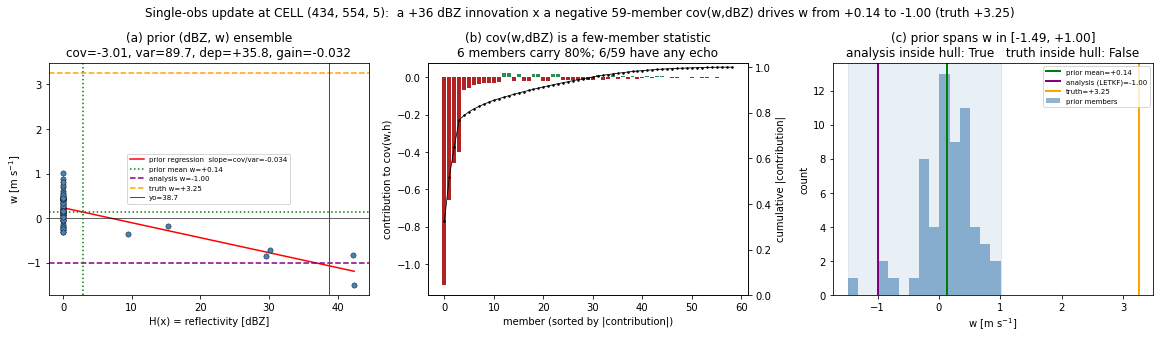

The prior regression slope cov/var = -0.034 m/s per dBZ is NEGATIVE, so brightening the cell (dep=+36) pushes w DOWN. Only 6 of 59 members carry echo; they set the whole covariance. The truth (+3.25) is outside the prior spread -- the ensemble cannot reach it.


In [11]:
# ===========================================================================
# Step-by-step diagnostics for CELL: why the update flips w.
# ===========================================================================
w_m = xf[:, IW]                       # prior w per member
h_m = h                               # prior H(x) per member (dBZ)
contrib = (w_m - xm[IW]) * (h_m - hm) / (Ne - 1)     # per-member contribution to cov(w,h)
w_a_letkf = xa_L[:, IW].mean()

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)

# (a) the regression that sets the gain
ax[0].scatter(h_m, w_m, s=28, c='steelblue', edgecolors='k', linewidths=.4, zorder=3)
hh = np.linspace(h_m.min(), max(h_m.max(), yo), 50)
ax[0].plot(hh, xm[IW] + cov / var * (hh - hm), 'r-', lw=1.5,
           label=f'prior regression  slope=cov/var={cov/var:+.3f}')
ax[0].axhline(0, c='k', lw=.6); ax[0].axhline(xm[IW], c='g', ls=':', label=f'prior mean w={xm[IW]:+.2f}')
ax[0].axhline(w_a_letkf, c='purple', ls='--', label=f'analysis w={w_a_letkf:+.2f}')
ax[0].axhline(TRUTH[CELL][IW], c='orange', ls='--', label=f'truth w={TRUTH[CELL][IW]:+.2f}')
ax[0].axvline(hm, c='g', ls=':'); ax[0].axvline(yo, c='r', ls='-', lw=1, label=f'yo={yo:.1f}')
ax[0].set_xlabel('H(x) = reflectivity [dBZ]'); ax[0].set_ylabel('w [m s$^{-1}$]')
ax[0].set_title(f'(a) prior (dBZ, w) ensemble\ncov={cov:+.2f}, var={var:.1f}, dep={dep:+.1f}, gain={cov/(var+R0):+.3f}')
ax[0].legend(fontsize=7, loc='best')

# (b) how few members carry the covariance
order = np.argsort(np.abs(contrib))[::-1]
csum = np.cumsum(np.abs(contrib[order])) / np.abs(contrib).sum()
ax[1].bar(range(Ne), contrib[order], color=np.where(contrib[order] < 0, 'firebrick', 'seagreen'))
ax[1].set_xlabel('member (sorted by |contribution|)'); ax[1].set_ylabel('contribution to cov(w,h)')
n80 = int(np.searchsorted(csum, 0.80)) + 1
ax[1].set_title(f'(b) cov(w,dBZ) is a few-member statistic\n{n80} members carry 80%; '
                f'{int((h_m>0).sum())}/{Ne} have any echo')
axt = ax[1].twinx(); axt.plot(range(Ne), csum, 'k.-', ms=3, lw=.8); axt.set_ylim(0, 1.02)
axt.set_ylabel('cumulative |contribution|')

# (c) prior hull vs analysis vs truth
ax[2].hist(w_m, bins=15, color='steelblue', alpha=.6, label='prior members')
for x_, c_, l_ in [(xm[IW], 'g', 'prior mean'), (w_a_letkf, 'purple', 'analysis (LETKF)'),
                   (TRUTH[CELL][IW], 'orange', 'truth')]:
    ax[2].axvline(x_, c=c_, lw=2, label=f'{l_}={x_:+.2f}')
ax[2].axvspan(w_m.min(), w_m.max(), color='steelblue', alpha=.12)
ax[2].set_xlabel('w [m s$^{-1}$]'); ax[2].set_ylabel('count')
inside_a = w_m.min() <= w_a_letkf <= w_m.max(); inside_t = w_m.min() <= TRUTH[CELL][IW] <= w_m.max()
ax[2].set_title(f'(c) prior spans w in [{w_m.min():+.2f}, {w_m.max():+.2f}]\n'
                f'analysis inside hull: {inside_a}   truth inside hull: {inside_t}')
ax[2].legend(fontsize=7)

fig.suptitle(f'Single-obs update at CELL {CELL}:  a +{dep:.0f} dBZ innovation x a negative '
             f'{Ne}-member cov(w,dBZ) drives w from {xm[IW]:+.2f} to {w_a_letkf:+.2f} '
             f'(truth {TRUTH[CELL][IW]:+.2f})', fontsize=12)
plt.show()

print(f'The prior regression slope cov/var = {cov/var:+.3f} m/s per dBZ is NEGATIVE, so brightening '
      f'the cell (dep=+{dep:.0f}) pushes w DOWN. Only {int((h_m>0).sum())} of {Ne} members carry echo; '
      f'they set the whole covariance. The truth ({TRUTH[CELL][IW]:+.2f}) is '
      f'{"outside" if not inside_t else "inside"} the prior spread -- the ensemble cannot reach it.')

## Verdict

If **Validation 1** and **Validation 2** pass, the assimilation code is correct: a hand-written
NumPy update, using only the cell's prior ensemble and the single observation, reproduces both the
Fortran solver and the stored production analysis to float32 precision. The strong downdraft is
therefore **not a bug** — it is exactly what a linear update produces from these conditions:

- a huge positive departure (`dep ≈ +36 dBZ`: the cell is nearly clear in the prior, bright in the obs);
- a **negative** `cov(w, dBZ)` carried by only a handful of echo-bearing members;
- so the gain `cov/(var+R)` is negative, and `Δw = dep · gain < 0` drives `w` below zero;
- the truth lies outside the prior ensemble's range, so no linear combination of members can reach it.

Because this holds at **loc = 0.1 km with a single observation**, localization and neighbouring
observations are provably not involved here. Whatever *additional* degradation appears at
**loc = 2.0 km** must therefore originate in the localization or in the covariances induced by the
neighbouring observations — that is the next thing to investigate, and it is a genuinely different
question from "is the update code correct".

### Reusing this notebook

Set `CELL` (cell 1) to any point in `CANDIDATES`, or add a point to `CANDIDATES` (cell 5) and
re-run from cell 6 (the ~53 s ensemble load). The `worse-than-prior` list finds points where
`|error_a| > |error_f|` for `w`. Everything downstream — the three validations and the diagnostic
figure — retargets automatically.

Mechanism and the domain-wide statistics: `S7_SignFlip_Mechanism.ipynb`. Field-level views:
`S8_CrossSection_Panels.ipynb`.